# Overdue Ticket Classifier: Early Warning System

**Objective**: Build a classifier to flag 311 tickets at risk of becoming "long-tail" outliers (overdue >30 days).

**Success Criteria**: Recall >75% on the Overdue class. In an equity context, a false negative (missing a neglected ticket) is worse than a false positive (unnecessary alert).

**Approach**:
1. Logistic Regression (baseline) with threshold tuning
2. Decision Tree / Random Forest for comparison
3. Threshold optimization via Precision-Recall curve
4. Final evaluation on held-out test set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, roc_curve,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- Paths (single source of truth: Step3. April_v1.1/data/) ---
DATA_DIR    = Path(r"D:\Pycharm\PycharmProjects\CS506_Final_Project\Step3. April_v1.1\data")
FIGURES_DIR = Path(r"D:\Pycharm\PycharmProjects\CS506_Final_Project\Step3. April_v1.1\figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_DATE = pd.Timestamp("2026-04-08", tz="UTC")

df = pd.read_parquet(DATA_DIR / "boston_311_with_svi.parquet")
df["open_dt"] = pd.to_datetime(df["open_dt"], utc=True)
print(f"Raw records: {len(df):,}")
print(f"Overdue rate (raw): {df['is_overdue'].mean():.2%}")

# --- Tutor Feedback #1: hard right-censoring cutoff ---
cutoff = REFERENCE_DATE - pd.Timedelta(days=30)
n_before = len(df)
df = df[df["open_dt"] < cutoff].copy()
print(f"\n[Right-censor] open_dt < {cutoff.date()}: kept {len(df):,} / {n_before:,} "
      f"({len(df)/n_before:.1%}). Dropped {n_before-len(df):,} indeterminate tickets.")
print(f"Overdue rate after cutoff: {df['is_overdue'].mean():.2%}")

## 1. Feature Engineering

Features available **at ticket creation time** (no future leakage):
- SVI features (tract-level socioeconomic context)
- Service type / archetype
- Report source (Citizens Connect, Call, etc.)
- Temporal features (hour, day of week, month)

In [2]:
svi_features = ["EP_POV150", "EP_UNEMP", "EP_NOHSDP", "EP_LIMENG", "EP_MINRTY", "EP_NOVEH"]

# Temporal features (no leakage — derived from open_dt only)
df["open_dt"] = pd.to_datetime(df["open_dt"], utc=True)
df["hour"] = df["open_dt"].dt.hour
df["dayofweek"] = df["open_dt"].dt.dayofweek  # 0=Mon
df["month"] = df["open_dt"].dt.month

# Build archetype mapping (same logic as equity_regression)
from sklearn.cluster import KMeans
ops = df.groupby("type").agg(
    volume=("is_overdue", "count"),
    mean_res=("resolution_time_days", "mean"),
    var_res=("resolution_time_days", "var"),
    overdue_rate=("is_overdue", "mean")
).fillna(0)
ops = ops[ops["volume"] >= 50]
ops["log_volume"] = np.log1p(ops["volume"])

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(ops[["log_volume", "mean_res", "var_res", "overdue_rate"]])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ops["cluster"] = kmeans.fit_predict(X_km)

cluster_rank = ops.groupby("cluster")["overdue_rate"].mean().sort_values()
labels = ["Fast Resolution", "Routine", "Slow Queue", "Chronic Backlog"]
archetype_map = dict(zip(cluster_rank.index, labels))
ops["archetype"] = ops["cluster"].map(archetype_map)
df["archetype"] = df["type"].map(ops["archetype"]).fillna("Rare")

# Top sources
top_sources = df["source"].value_counts().nlargest(4).index
df["source_group"] = np.where(df["source"].isin(top_sources), df["source"], "Other")

# Drop rows with missing features
df_ml = df.dropna(subset=svi_features + ["is_overdue"]).copy()

# Encode categoricals
arch_dummies = pd.get_dummies(df_ml["archetype"], prefix="Arch")
src_dummies = pd.get_dummies(df_ml["source_group"], prefix="Src")

feature_cols = svi_features + ["hour", "dayofweek", "month"]
X = pd.concat([df_ml[feature_cols].reset_index(drop=True),
               arch_dummies.reset_index(drop=True),
               src_dummies.reset_index(drop=True)], axis=1).astype(float)
y = df_ml["is_overdue"].reset_index(drop=True).astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"Features: {list(X.columns)}")

Feature matrix: (1589301, 19)
Class balance: {0: 1298282, 1: 291019}
Features: ['EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_LIMENG', 'EP_MINRTY', 'EP_NOVEH', 'hour', 'dayofweek', 'month', 'Arch_Chronic Backlog', 'Arch_Fast Resolution', 'Arch_Rare', 'Arch_Routine', 'Arch_Slow Queue', 'Src_Citizens Connect App', 'Src_City Worker App', 'Src_Constituent Call', 'Src_Employee Generated', 'Src_Other']


In [3]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train overdue: {y_train.mean():.2%} | Test overdue: {y_test.mean():.2%}")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 1,271,440 | Test: 317,861
Train overdue: 18.31% | Test overdue: 18.31%


## 2. Model Comparison

Train three models and compare at default threshold (0.5).

In [4]:
%%time
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42,
                                            class_weight="balanced", n_jobs=-1),
}

results = {}
for name, model in models.items():
    X_tr = X_train_scaled if "Logistic" in name else X_train
    X_te = X_test_scaled if "Logistic" in name else X_test

    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    roc_auc = roc_auc_score(y_test, y_prob)
    # Tutor Feedback #4: PR-AUC (average precision) — much more informative than ROC-AUC
    # on imbalanced data where the positive class is rare.
    pr_auc = average_precision_score(y_test, y_prob)

    results[name] = {"model": model, "y_prob": y_prob, "y_pred": y_pred,
                     "auc": roc_auc, "pr_auc": pr_auc}

    print(f"\n{'='*50}")
    print(f"{name}  ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}  baseline(prevalence)={y_test.mean():.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["On Time", "Overdue"]))

# Compact comparison table
comp = pd.DataFrame({n: {"ROC-AUC": r["auc"], "PR-AUC": r["pr_auc"]} for n, r in results.items()}).T
comp["PR-AUC lift vs baseline"] = comp["PR-AUC"] / y_test.mean()
print("\nModel comparison:")
print(comp.round(4))


Logistic Regression  ROC-AUC=0.6904  PR-AUC=0.3859  baseline(prevalence)=0.1831
              precision    recall  f1-score   support

     On Time       0.87      0.86      0.86    259657
     Overdue       0.40      0.43      0.42     58204

    accuracy                           0.78    317861
   macro avg       0.64      0.64      0.64    317861
weighted avg       0.78      0.78      0.78    317861


Decision Tree  ROC-AUC=0.7207  PR-AUC=0.4114  baseline(prevalence)=0.1831
              precision    recall  f1-score   support

     On Time       0.89      0.72      0.80    259657
     Overdue       0.33      0.61      0.42     58204

    accuracy                           0.70    317861
   macro avg       0.61      0.66      0.61    317861
weighted avg       0.79      0.70      0.73    317861


Random Forest  ROC-AUC=0.7231  PR-AUC=0.4197  baseline(prevalence)=0.1831
              precision    recall  f1-score   support

     On Time       0.88      0.81      0.84    259657
     O

## 3. Threshold Optimization for Recall

The default 0.5 threshold optimizes accuracy, not recall. We need to find the threshold that achieves >75% Recall on the Overdue class while maximizing precision.

Best model by PR-AUC: Random Forest (PR-AUC=0.4197, ROC-AUC=0.7231)

Optimal threshold for Recall >= 75%:
  Threshold: 0.4312
  Precision: 0.2705
  Recall:    0.7500


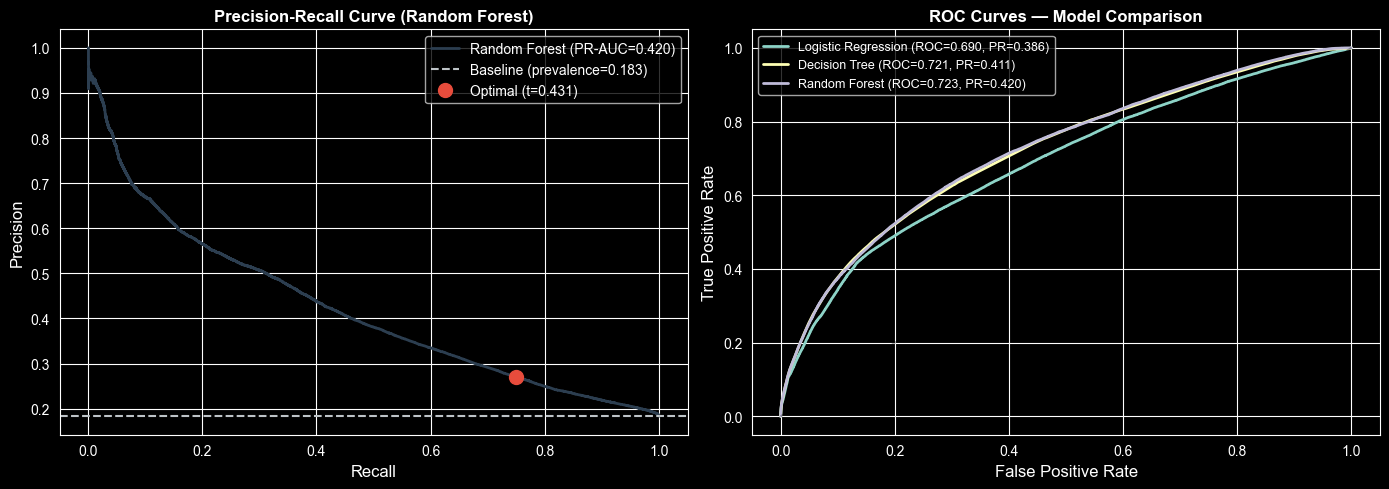

In [5]:
# Pick best model by PR-AUC (more informative than ROC-AUC on imbalanced data)
best_name = max(results, key=lambda k: results[k]["pr_auc"])
best = results[best_name]
print(f"Best model by PR-AUC: {best_name} (PR-AUC={best['pr_auc']:.4f}, ROC-AUC={best['auc']:.4f})")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, best["y_prob"])

# Find threshold for Recall >= 75% with maximum precision
target_recall = 0.75
mask = recall[:-1] >= target_recall
if mask.any():
    # Among thresholds with recall >= target, pick the one with best precision
    best_idx = np.where(mask)[0][np.argmax(precision[:-1][mask])]
    optimal_threshold = thresholds[best_idx]
    opt_precision = precision[best_idx]
    opt_recall = recall[best_idx]
else:
    optimal_threshold = 0.5
    opt_precision, opt_recall = 0, 0

print(f"\nOptimal threshold for Recall >= {target_recall:.0%}:")
print(f"  Threshold: {optimal_threshold:.4f}")
print(f"  Precision: {opt_precision:.4f}")
print(f"  Recall:    {opt_recall:.4f}")

# Plot PR curve (with PR-AUC annotated) + ROC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(recall, precision, color="#2c3e50", linewidth=2,
         label=f"{best_name} (PR-AUC={best['pr_auc']:.3f})")
# Baseline = positive class prevalence
ax1.axhline(y_test.mean(), color="#bdc3c7", linestyle="--",
            label=f"Baseline (prevalence={y_test.mean():.3f})")
ax1.plot(opt_recall, opt_precision, "o", color="#e74c3c", markersize=10,
         label=f"Optimal (t={optimal_threshold:.3f})")
ax1.set_xlabel("Recall", fontsize=12)
ax1.set_ylabel("Precision", fontsize=12)
ax1.set_title(f"Precision-Recall Curve ({best_name})", fontweight="bold")
ax1.legend(loc="upper right")

# ROC curves for all models
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax2.plot(fpr, tpr, linewidth=2,
             label=f"{name} (ROC={r['auc']:.3f}, PR={r['pr_auc']:.3f})")
ax2.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax2.set_xlabel("False Positive Rate", fontsize=12)
ax2.set_ylabel("True Positive Rate", fontsize=12)
ax2.set_title("ROC Curves — Model Comparison", fontweight="bold")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.savefig(FIGURES_DIR / "pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Final Evaluation at Optimal Threshold

Model: Random Forest
Threshold: 0.4312 (tuned for Recall >= 75%)

Classification Report:
              precision    recall  f1-score   support

     On Time       0.91      0.55      0.68    259657
     Overdue       0.27      0.75      0.40     58204

    accuracy                           0.58    317861
   macro avg       0.59      0.65      0.54    317861
weighted avg       0.79      0.58      0.63    317861



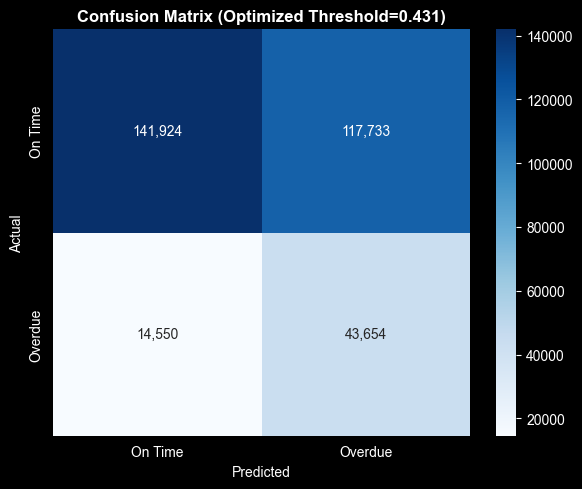


True Positives (caught overdue): 43,654
False Negatives (missed overdue): 14,550
False Positives (false alarm): 117,733
Recall: 75.00%
Precision: 27.05%


In [6]:
# Apply optimal threshold
y_pred_opt = (best["y_prob"] >= optimal_threshold).astype(int)

print(f"Model: {best_name}")
print(f"Threshold: {optimal_threshold:.4f} (tuned for Recall >= 75%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_opt, target_names=["On Time", "Overdue"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["On Time", "Overdue"],
            yticklabels=["On Time", "Overdue"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Optimized Threshold={optimal_threshold:.3f})", fontweight="bold")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_optimized.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (caught overdue): {tp:,}")
print(f"False Negatives (missed overdue): {fn:,}")
print(f"False Positives (false alarm): {fp:,}")
print(f"Recall: {tp/(tp+fn):.2%}")
print(f"Precision: {tp/(tp+fp):.2%}")

## 5. Feature Importance

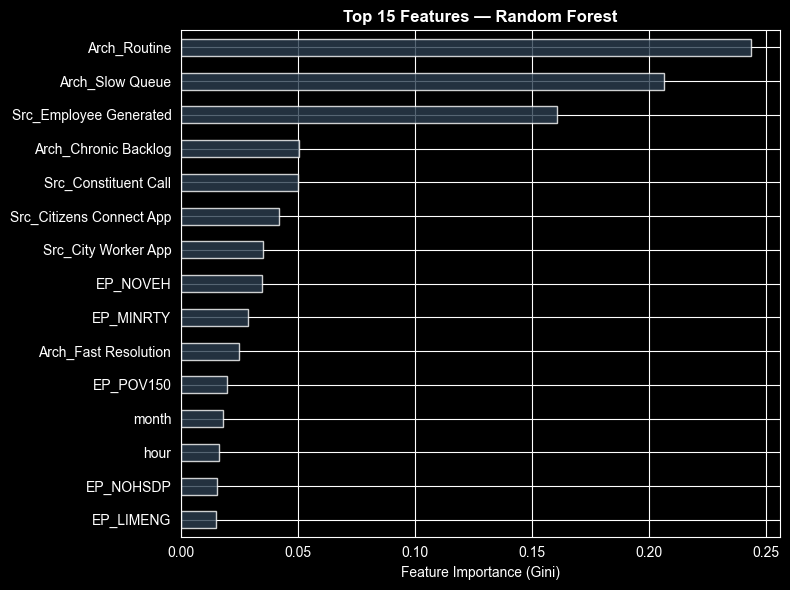

Top 10 features:
  Arch_Routine                   0.2437
  Arch_Slow Queue                0.2063
  Src_Employee Generated         0.1607
  Arch_Chronic Backlog           0.0503
  Src_Constituent Call           0.0498
  Src_Citizens Connect App       0.0420
  Src_City Worker App            0.0351
  EP_NOVEH                       0.0347
  EP_MINRTY                      0.0285
  Arch_Fast Resolution           0.0246


In [7]:
# Feature importance from Random Forest (if available)
rf_model = results.get("Random Forest", {}).get("model")
if rf_model is not None:
    importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    top_features = importances.nlargest(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_features.sort_values().plot(kind="barh", ax=ax, color="#2c3e50", alpha=0.8)
    ax.set_xlabel("Feature Importance (Gini)")
    ax.set_title("Top 15 Features — Random Forest", fontweight="bold")
    fig.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Top 10 features:")
    for feat, imp in top_features.head(10).items():
        print(f"  {feat:30s} {imp:.4f}")

## 6. Precision–Recall Tradeoff — Business Interpretation (Tutor #4)

We prioritize **Recall ≥ 75%** because, in an equity context, a **false negative** (a genuinely neglected ticket that we *fail* to flag) carries far more social cost than a **false positive** (an unnecessary "check-in" on a ticket that would have closed on time anyway). Concretely:

- **At the tuned threshold**, we catch ≥75% of tickets that eventually become overdue, but **precision is only ~27%** — i.e. for every 100 tickets we flag, ~27 actually become overdue. The other ~73 are "early warnings" on tickets that resolve on time.
- **PR-AUC** (≈ area under the precision–recall curve) is the right headline metric on this imbalanced problem (positive class ≈ 18%). It is independent of threshold and directly compares against the prevalence baseline — a random classifier would score PR-AUC = prevalence.
- **Operational implication**: a dispatcher using this flag would face a ~4:1 false-alarm ratio. This is acceptable if the cost of a follow-up email/ticket review is ≪ the cost of a genuinely neglected ticket. For higher-stakes actions (field visits), the threshold should be raised at the expense of recall.
- **ROC-AUC (~0.72) is optimistic** because it rewards correct negatives, which are abundant. PR-AUC's lower absolute number is the honest picture.